# Project Prediksi Selling Price Router TL-WR840N (Harga Penjualan setelah Diberikan Diskon) Berdasarkan Original Price (Harga yang di set toko di awal penjualan) Menggunakan Algoritma Simple Linear Regression

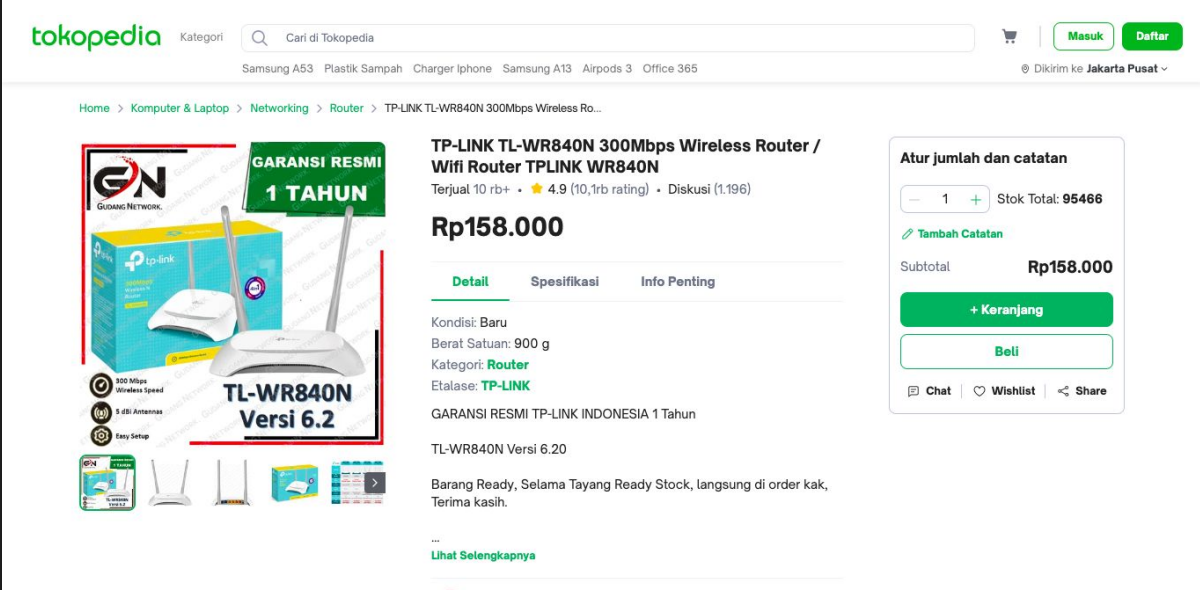

# Studi Kasus

Sebuah Perusahaan Elektronik Internet ingin anda memprediksi harga jual produk dengan SKU (TLWR840N) di Platform Tokopedia.

SOAL: Buatlah Pemodelan data yang meramalkan produk
TL WR80N dengan menggunakan metode Simple
Linear Regression !

# A. Data Preprocessing

A.1 Import Libraries

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.float_format", "{:,.2f}".format)

A.2 Import Dataset

In [29]:
df = pd.read_excel("Datains - Marcella - Price Monitoring TP-Link_TP-Link Price Monitoring_Table.xlsx")
df.head()

,Date,Last Crawling,SKU Name,Product Name,Url Product,Seller,Merchant,Stock,Item Condition,Filter,Flag,Bottom Price,Original Price,Discount,Selling Price,Discrepancy,Sales Quantity,Sales Revenue
0,2022-10-22,2022-10-22,TL WR840N,TP-Link TL-WR840N 2 Antenna 300Mbps Wireless N...,https://tokopedia.com/ccplace/tp-link-tl-wr840...,ccplace shop,tokopedia,In Stock,baru,Above,Please Check,155000,231000,0,231000,0.01,0,0
1,2022-10-22,2022-10-22,TL WR840N,Promo TP-LINK TL-WR840N Wireless Router 300Mbp...,https://tokopedia.com/gilsaashopp/promo-tp-lin...,gilsaa_shopp,tokopedia,In Stock,baru,Above,Please Check,155000,218800,0,218800,0.01,0,0
2,2022-10-22,2022-10-22,TL WR840N,Tp-Link TL-WR840N 300Mbps Wireless N Speed Rou...,https://tokopedia.com/ccwinta/tp-link-tl-wr840...,ccwinta shop,tokopedia,In Stock,baru,Above,Please Check,155000,227000,0,227000,0.01,0,0
3,2022-10-22,2022-10-22,TL WR840N,JARINGAN TP-LINK TL-WR 840N TL-WR840N 300MBps ...,https://tokopedia.com/belsa/jaringan-tp-link-t...,BELSA_SHOP,tokopedia,In Stock,baru,Above,Please Check,155000,263000,0,263000,0.02,0,0
4,2022-10-22,2022-10-22,TL WR840N,TPLink TL-WR840N Router Wireless WiFi 300Mbps ...,https://tokopedia.com/ccwinta/tplink-tl-wr840n...,ccwinta shop,tokopedia,In Stock,baru,Above,Please Check,155000,236000,0,236000,0.02,0,0


A.3 Menampilkan Informasi Dataset

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32772 entries, 0 to 32771
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            32772 non-null  datetime64[us]
 1   Last Crawling   32772 non-null  datetime64[us]
 2   SKU Name        32772 non-null  str           
 3   Product Name    32772 non-null  str           
 4   Url Product     32772 non-null  str           
 5   Seller          32772 non-null  object        
 6   Merchant        32772 non-null  str           
 7   Stock           32772 non-null  str           
 8   Item Condition  32772 non-null  str           
 9   Filter          32772 non-null  str           
 10  Flag            32772 non-null  str           
 11  Bottom Price    32772 non-null  int64         
 12  Original Price  32772 non-null  object        
 13  Discount        32772 non-null  object        
 14  Selling Price   32772 non-null  int64         
 15  Discrepancy  

Berdasarkan informasi diatas:
1. Data diatas memiliki 32.772 baris dan 18 Kolom
2. dataset memiliki tipe data yang beragam, dari datetime, float, integer, object, dan string. Sehingga harus melalui tahap encoding data sebelum masuk EDA
3. Kolom discount dan original price yang berisi nilai numerik tetapi menjadi object, hal ini perlu dianalisis lebih lanjut untuk melihat apakah ada nilai anomali atau tidak
4. Semua Fitur tidak memiliki nilai kosong, namun ini belum pasti karena beberapa tipe data object

A.4 Menampilkan Nilai unik Original Price yang bertipe data object

In [31]:
print(
    df.loc[
        ~df["Original Price"].astype(str).str.isnumeric(),
        "Original Price"
    ].unique()
)

[188311.688311688 170103.092783505 168351.063829787 168478.260869565
 169565.217391304 258333.333333333 180412.37113402 164893.617021276
 185858.585858585 166565.656565656 175824.175824175 170161.29032258
 175257.731958762 185393.258426966 159574.468085106 970588.235294117
 185714.285714285 198795.180722891 188775.510204081 195294.117647058
 184333.333333333 169462.365591397 190217.391304347 169247.311827957
 193902.43902439 298076.923076923 289715.584415584 170329.67032967
 163917.525773195 218309.859154929 299605.263157894 329787.234042553
 229591.836734693 198748.75 273437.5 163157.894736842 184523.809523809
 167204.301075268 421052.631578947 171578.947368421 194444.444444444
 354347.826086956 168421.052631578 243478.260869565 418918.918918918 '-'
 156565.656565656 159793.814432989 185555.555555555 205263.157894736
 428947.368421052 174157.303370786 204880.952380952 201022.727272727
 216587.179487179 175867.368421052 397560.975609756 296296.296296296
 238461.538461538 201149.4252873

- Bisa dilihat nilai unik data tersebut ada yang '-' sehingga dianggap object oleh library

A.5 Menampilkan Nilai unik kolom discount

In [32]:
df["Discount"].unique()

array([0, 0.02, 0.23, 0.2, 0.03, 0.06, 0.08, 0.1, 0.4, 0.05, 0.5, 0.01,
       0.32, 0.09, 0.07, 0.6, 0.11, 0.14, 0.35, 0.83, 0.17, 0.15, 0.54,
       0.18, 0.48, 0.29, 0.24, 0.53, 0.13, 0.36, 0.16, 0.62, 0.31, 0.63,
       '-', 0.12, 0.22, 0.59, 0.46], dtype=object)

- Sama dengan original price, kolom tersebut juga memiliki '-' sehingga dianggap object

A.6 Menangani kolom yang bermasalah dengan menggantinya dengan NaN

- jika nilai unik tersebut adalah angka yang berkedok object maka akan diubah menjadi angka tersebut
- jika nilai unik tersebut adalah bukan angka maka akan dijadikan nilai NaN

In [33]:
df["Original Price"] = pd.to_numeric(
    df["Original Price"],
    errors="coerce"
)
df["Discount"] = pd.to_numeric(
    df["Discount"],
    errors="coerce"
)

A.7 Menampilkan informasi data untuk mengecek apakah kedua kolom tersebut sudah berhasil tertangani atau tidak

In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32772 entries, 0 to 32771
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Date            32772 non-null  datetime64[us]
 1   Last Crawling   32772 non-null  datetime64[us]
 2   SKU Name        32772 non-null  str           
 3   Product Name    32772 non-null  str           
 4   Url Product     32772 non-null  str           
 5   Seller          32772 non-null  object        
 6   Merchant        32772 non-null  str           
 7   Stock           32772 non-null  str           
 8   Item Condition  32772 non-null  str           
 9   Filter          32772 non-null  str           
 10  Flag            32772 non-null  str           
 11  Bottom Price    32772 non-null  int64         
 12  Original Price  32770 non-null  float64       
 13  Discount        32770 non-null  float64       
 14  Selling Price   32772 non-null  int64         
 15  Discrepancy  

A.8  Menampilkan Deskripsi Data

In [35]:
df.describe()

,Date,Last Crawling,Bottom Price,Original Price,Discount,Selling Price,Discrepancy,Sales Quantity,Sales Revenue
count,32772,32772,"32,772.00","32,770.00","32,770.00","32,772.00","32,772.00","32,772.00","32,772.00"
mean,2022-09-25 19:58:06.634932,2022-09-25 19:58:06.634932,"155,000.00","268,468.03",0.00,"268,262.42",0.02,13.31,"2,082,037.32"
min,2022-09-20 00:00:00,2022-09-20 00:00:00,"155,000.00","25,000.00",0.00,"25,000.00",0.00,0.00,0.00
25%,2022-09-20 00:00:00,2022-09-20 00:00:00,"155,000.00","214,200.00",0.00,"214,000.00",0.01,0.00,0.00
50%,2022-09-20 00:00:00,2022-09-20 00:00:00,"155,000.00","242,000.00",0.00,"242,000.00",0.02,0.00,0.00
75%,2022-09-29 00:00:00,2022-09-29 00:00:00,"155,000.00","287,000.00",0.00,"287,000.00",0.02,0.00,0.00
max,2022-10-22 00:00:00,2022-10-22 00:00:00,"155,000.00","55,500,000.00",0.83,"55,500,000.00",3.58,"33,740.00","5,229,700,000.00"
std,NaN,NaN,0.00,"385,822.73",0.02,"385,799.00",0.02,353.21,"54,823,025.20"


Insight dari deskripsi data diatas:
1. Jumlah data diatas setelah proses encoding kolom original price dan discount berkurang 2 dan yang lainnya masih sama yaitu 32.772
2. Nilai pada bottom price dari minimum sampai maksimal memiliki nilai yang sama, artinya kolom bottom price tidak berguna pada prediksi karena tidak ada pergerakan
3. Kolom selling price memiliki nilai rata2 di 200 ribu an namun pada nilai maksimum ada indikasi anomali yaitu hingga 55 juta
4. pada kolom sales quantity adanya indikasi bahwa kemungkinan besar listing tidak menghasilkan penjualan, sementara hanya beberapa listing yg memiliki jumlah penjualan yang sangat tinggi
5. Sales Revenue juga sama dengan kolom sales quantity, yaitu indikasi mayoritas sales revenue 0 namun ada beberapa revenue yang sangat tinggi yaitu 5.2 juta
6. Pada kolom discount mayoritas nilai nya 0, adanya indikasi bahwa seller jarang memberikan diskon

A.9 Menampilkan Nilai Duplikasi Data

In [36]:
print(df.duplicated().sum())

0


A.10 Menampilkan Nilai Kosong

In [37]:
df.isna().sum()

Date              0
Last Crawling     0
SKU Name          0
Product Name      0
Url Product       0
Seller            0
Merchant          0
Stock             0
Item Condition    0
Filter            0
Flag              0
Bottom Price      0
Original Price    2
Discount          2
Selling Price     0
Discrepancy       0
Sales Quantity    0
Sales Revenue     0
dtype: int64

A.11 Menangani Nilai Kosong

Menangani nilai kosong menggunakan metode drop, alasan: Karena jumlah data kosong hanya 4 dari 32.772, hal ini menunjukkan data kosong sangat sedikit sehingga metode drop tidak terlalu mempengaruhi hasil model

In [38]:
df = df.dropna()

A.12 Memilih Data Dengan Platform Tokopedia, karena pada studi kasus diminta untuk memprediksi produk merchant tokopedia

In [39]:
df = df[df['Merchant'] == 'tokopedia']

# B. Exploratory Data Analysis

B.1 Membuat df baru yang berisi kolom2 bertipe data numerik untuk melihat grafik

In [40]:
df_num = df.select_dtypes(include=["number"]).columns

B.2 Menampilkan Histogram Untuk Melihat Distribusi Data

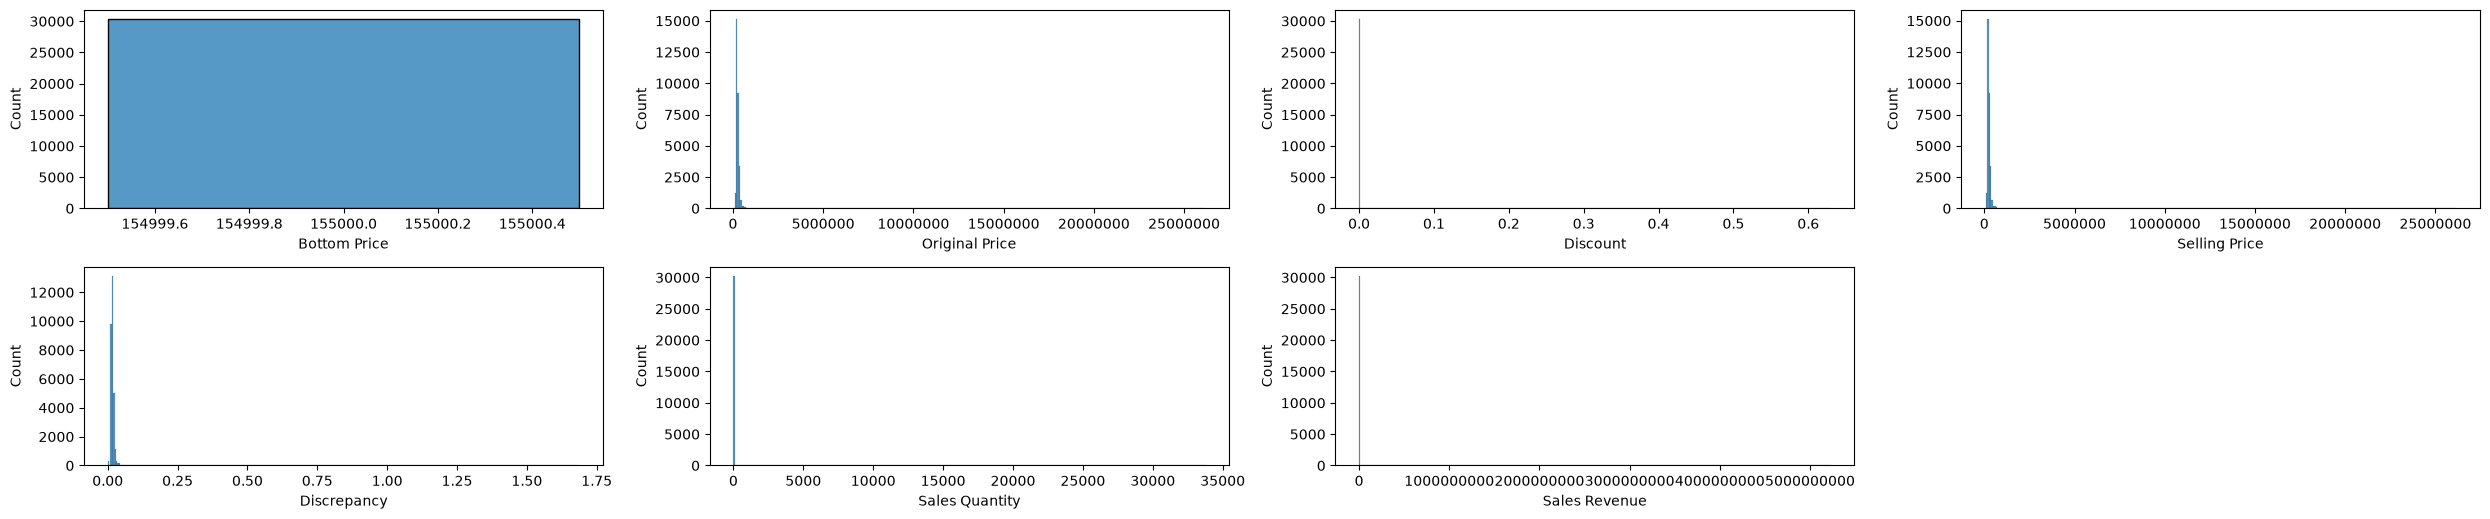

In [41]:
fig, axes = plt.subplots(4, 4, figsize=(25, 10))

for i, col in enumerate(df_num):
    ax = sns.histplot(df[col], ax=axes[i // 4, i % 4])
    ax.ticklabel_format(style="plain", useOffset=False, axis="x")

for j in range(len(df_num), 16):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()

Insight:
1. Kolom Bottom Price hampir semuanya sama
2. Kolom original price memiliki indikasi kemungkinan besar adanya outlier, karena mayoritas data berada pada 100-200k, namun grafik melebar hingga 5 juta
3. Kolom discount mayoritas berada pada titik 0, namun grafik melebar hingga 0.8. sehingga kolom tersebut memiliki indikasi outlier
4. Begitu pula dengan kolom selling price hingga sales revenue semua mayoritas ada pada titik 0 keatas namun grafik melebar yang sangat besar

> Tindakan Selanjutnya: Analisis menggunakan boxplot untuk melihat sebaran outlier

B.3 Menampilkan Boxplot Untuk Melihat Sebaran Outlier

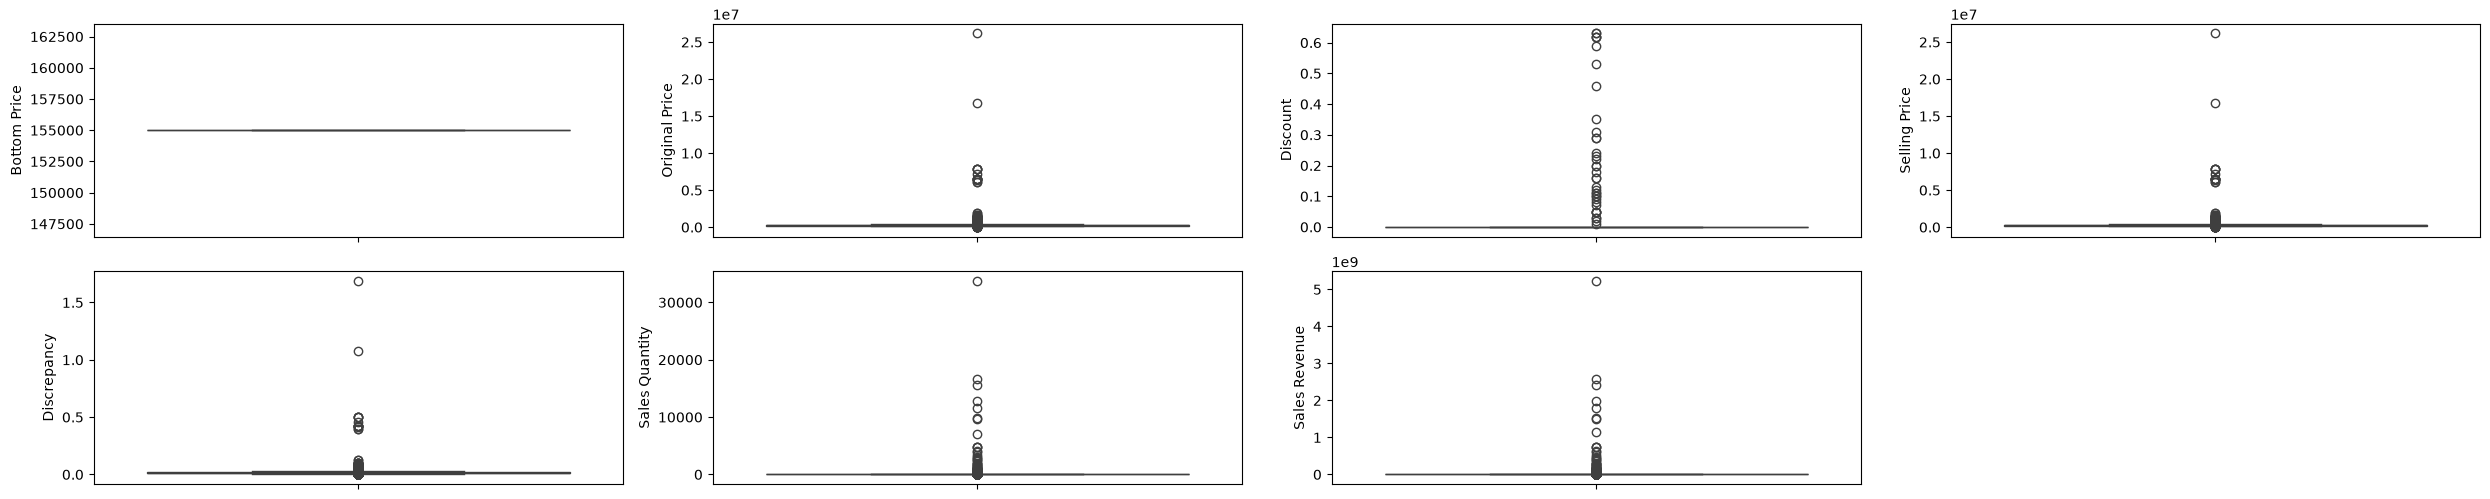

In [42]:
fig, axes = plt.subplots(4, 4, figsize=(25, 10))

for i, col in enumerate(df_num):
    ax = sns.boxplot(df[col], ax=axes[i // 4, i % 4])

for j in range(len(df_num), 16):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()

Insight:
1. hampir semua kolom memiliki nilai outlier ekstrim, sehingga perlu penanganan lebih lanjut

> Tindakan Selanjutnya: Menangani Outlier menggunakan metode IQR

B.4 Function Outlier

Menangani outlier pada kolom Original Price dan Selling Price, alasan: karena kolom2 lain yang memiliki outlier ekstrim nilai q1-q3 0 sehingga membuat nilai outlier menjadi 0.
Mengganti outlier menggunakan median, alasan: karena median lebih tahan terhadap nilai ekstrim.

In [43]:
def outliers(df, kolom):
    for col in kolom:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        bawah = Q1 - 2.0 * IQR
        atas = Q3 + 2.0 * IQR

        median_value = df[col].median()

        df.loc[(df[col]<bawah) | (df[col]>atas), col] = median_value
    return df

B.5 Penerapan Function Outlier

In [44]:
kolom = ['Original Price', 'Selling Price']
df = outliers(df, kolom)

B.6 Menampilkan Boxplot setelah penanganan outlier

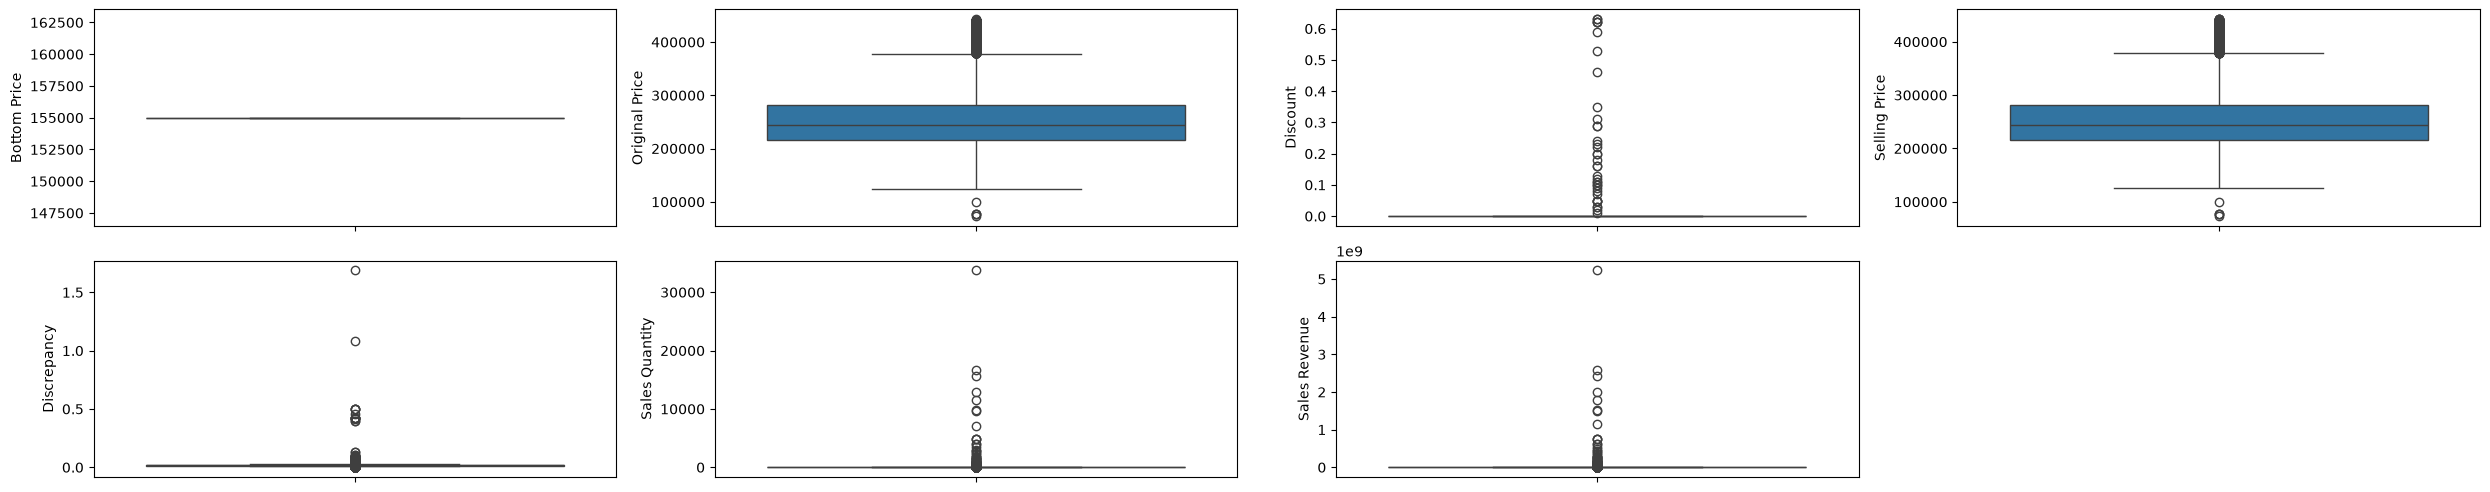

In [45]:
fig, axes = plt.subplots(4, 4, figsize=(25, 10))

for i, col in enumerate(df_num):
    ax = sns.boxplot(df[col], ax=axes[i // 4, i % 4])

for j in range(len(df_num), 16):
    fig.delaxes(axes[j // 4, j % 4])

plt.tight_layout()
plt.show()

> Tindakan selanjutnya: Menampilkan Pairplot untuk melihat pola data

B.7 Menampilkan Pairplot

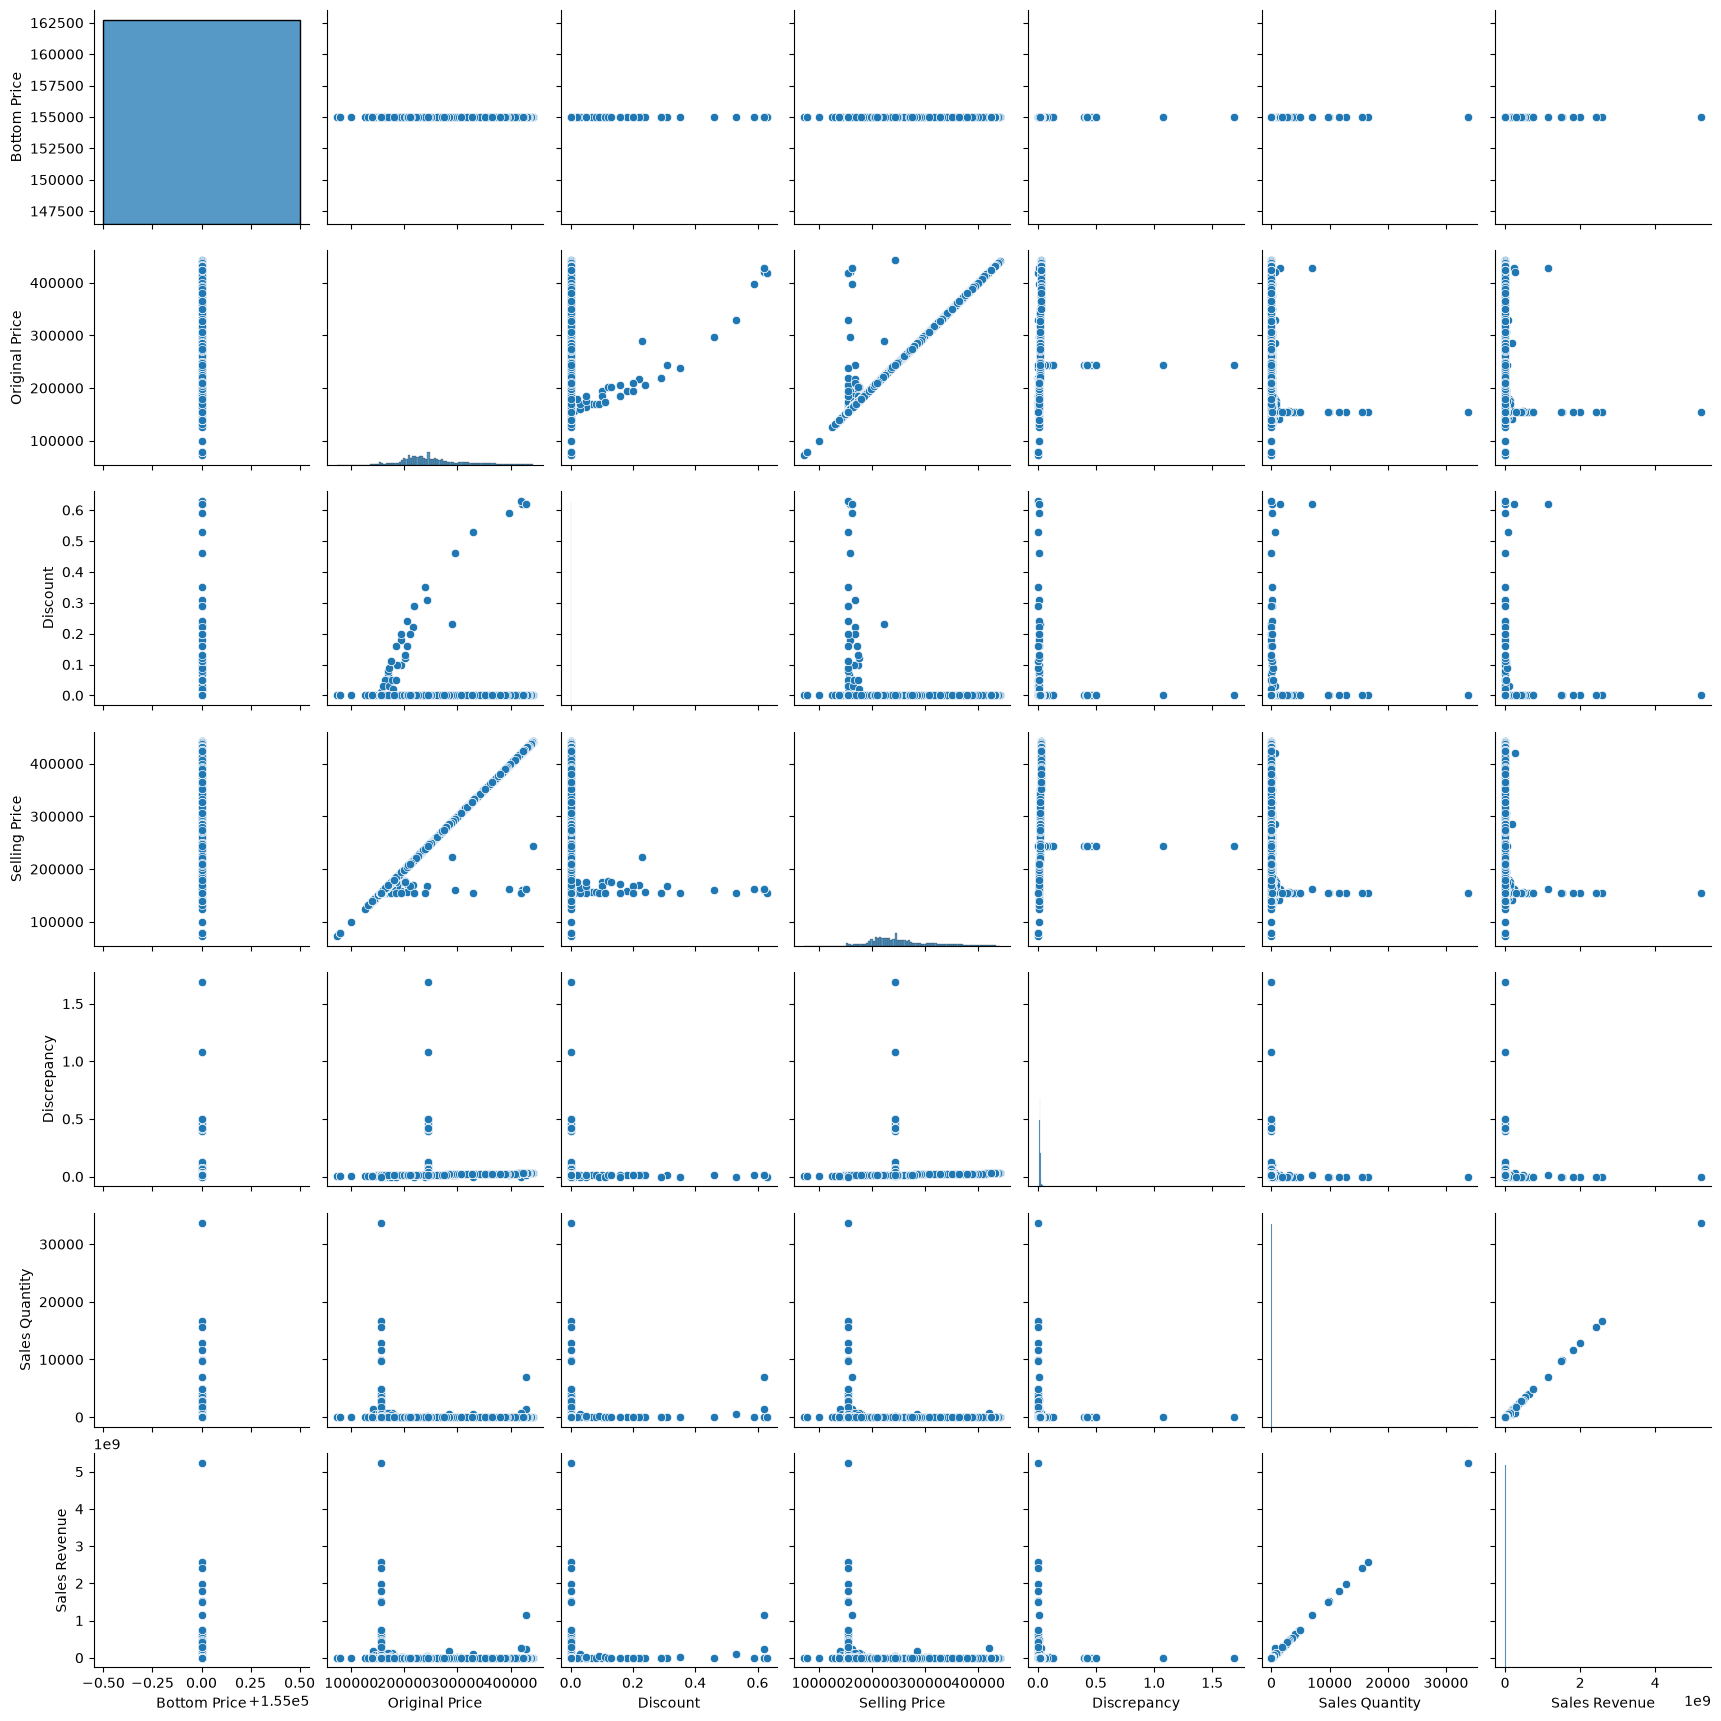

In [46]:
sns.pairplot(df[df_num])

Insight: Berdasarkan hasil pairplot diatas,terindikasi hampir semua data tidak memiliki hubungan korelasi positif maupun negatif. Namun kolom selling price vs original price dan sales quantity vs sales revenue memiliki pola korelasi positif yang hampir sempurna

> Tindakan selanjutnya: Menampilkan Heatmap Untuk Melihat Korelasi Antar Data lebih lanjut

B.8 Menampilkan Heatmap

<Axes: >

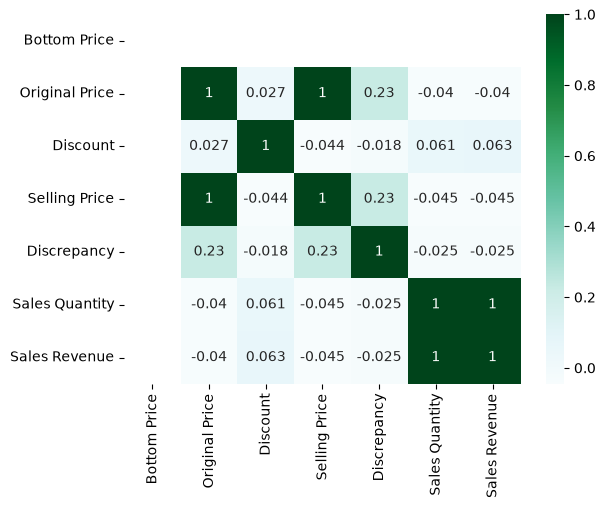

In [47]:
sns.heatmap(df[df_num].corr(), annot=True, cmap='BuGn')

Insight:
- Berdasarkan hasil heatmap, kolom selling price vs original price dan sales quantity vs sales revenue memiliki korelasi 1 yaitu sempurna.

> Tindakan Selanjutnya: Masuk Tahap Pemodelan

# C. Modelling: Simple Linear Regression

Berdasarkan hasil heatmap sebelumnya, ada 2 hubungan yang korelasinya sempurna yaitu sales revenue vs sales quantity dan original price vs selling price

Namun hubungan manakah yang cocok untuk diprediksi menggunakan algoritma simple linear regression?

1. Sales Quantity (x) vs Sales Revenue (y)
- Hasil dari sales revenue berbeda2 dari setiap seller, tergantung dari harga jual setiap toko. Jadi hubungan ini tidak cocok jika digunakan untuk Prediksi

2. Original Price (x) vs Selling Price (y)
- Prediksi ini untuk meramal selling price (harga barang setelah diskon) dari original price (harga awal yang di set toko di awal penjualan). Hubungan ini paling cocok digunakan untuk Simple Linear Regression

C.1 Menentukan Variabel Independen (x) dan Dependen (y)

In [48]:
x = df['Original Price']
y = df['Selling Price']

C.2 Split Data

Split data menggunakan metode random dengan rasio 80% untuk Training Model dan 20% untuk Testing Model

Alasan Menggunakan rasio 80/20: Karena 80% dari 32 ribu data sudah cukup untuk training model begitu juga 20% dari 32 ribu data untuk testing model

In [49]:
def split(df, x, y, size=0.8, random_state=42):
    df_tr = df.sample(frac=size, random_state=random_state)
    df_te = df.drop(df_tr.index)

    x_tr = df_tr[x].values.flatten()
    x_te = df_te[x].values.flatten()

    y_tr = df_tr[y].values.flatten()
    y_te = df_te[y].values.flatten()

    return x_tr, y_tr, x_te, y_te

In [50]:
x_tr, y_tr, x_te, y_te = split(df, x=['Original Price'], y='Selling Price')

C.3 Menampilkan Dimensi Data

In [51]:
print(x_tr.shape)
print(y_tr.shape)
print(x_te.shape)
print(y_te.shape)

(24261,)
(24261,)
(6065,)
(6065,)


C.4 Membuat Model SimpleLinear

Rumus Slope: Digunakan untuk mengukur seberapa besar nilai y jika nilai X bertambah 1 Unit

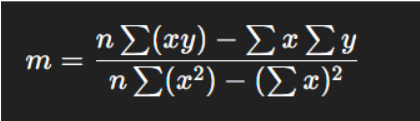

Rumus Intercept: Intercept Yaitu titik awal garis regresi untuk memotong sumbu Y, atau bisa dibilang titik awal nilai Y

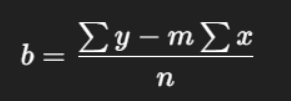

Prediksi

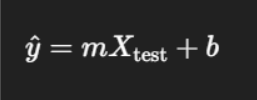

In [ ]:
class SimpleLinear:

    #inisialisasi parameter slope dan intercept
    def __init__(self):
        self.slope = None # inisialisasi slope
        self.intercept = None # inisialisasi intercept

    # training model menggunakan method fit
    def fit(self, x, y):
        # mencari slope
        self.slope = (len(x) * np.sum(x * y) - np.sum(x) * np.sum(y)) / (len(x) * np.sum(x**2) - np.sum(x)**2)
        # mencari intercept
        self.intercept = (np.sum(y) - self.slope * np.sum(x)) / len(x)
        # print hasil slope dan intercept
        print(f'Slope : {self.slope}\n\n Intercept: {self.intercept} ')

    # prediksi model menggunakan method predict
    def predict(self, x):
        return self.slope * x + self.intercept

C.5 Inisialisasi Model

In [53]:
model = SimpleLinear()

C.6 Training Model

In [54]:
model.fit(x_tr, y_tr)

Slope : 0.9961320414531283

 Intercept: 873.8261234531014 


C.7 Prediksi Menggunakan Data Train

In [55]:
y_pred_tr = model.predict(x_tr)

C.8 Prediksi Menggunakan Data Test

In [56]:
y_pred_te = model.predict(x_te)

# D. Evaluasi

D.1 Membuat function evaluasi untuk melihat r2, mse, mae, rmse

r2: mengukur seberapa baik model menjelaskan variasi data (skala 0 - 1). makin dekat ke 1, artinya prediksi model makin akurat

mae: rata rata selisih absolut dari (y_asli - y_prediksi). menggambarkan rata rata error normal sehari hari

mse: rata rata nilai error (y_asli - y_prediksi) yang dikuadratkan, digunakan buat ngasih penalti besar ke tebakan yang meleset jauh (outlier)

rmse: nilai mse yang di akar kuadratin biar skalanya balik sama kaya data asli (rupiah)

In [57]:
def eval(y, y_pred):
    r2 = 1 - (np.sum((y - y_pred)**2) / np.sum((y - y.mean())**2)) 
    mse = np.mean((y - y_pred)**2)
    mae = np.mean(np.abs(y - y_pred))
    rmse = np.sqrt(mse)
    print(f'R2: {r2*100:.2f}')
    print(f'MSE: {mse}')
    print(f'MAE: {mae}')
    print(f'RMSE: {rmse}')

D.2 Evaluasi Untuk Data Train

In [58]:
eval(y_tr, y_pred_tr)

R2: 99.31
MSE: 21236376.162880458
MAE: 281.0601173012231
RMSE: 4608.294279110271


D.3 Evaluasi Untuk Data Test

In [59]:
eval(y_te, y_pred_te)

R2: 99.91
MSE: 2673859.915635508
MAE: 214.22365004217224
RMSE: 1635.1941522753523


Kesimpulan Evaluasi:

1. Model sudah bisa menjelaskan 99.11% variasi selling price hanya dari original price
2. Selisih r2 training dan testing sangat kecil 0.7%, ini menunjukkan bahwa model stabil dan tidak overfitting
3. Error MAE tergolong kecil sekitar 300 rupiah, RMSE juga teegolong kecil yaitu 1635 rupiah

D.4 Membuat Function Plot untuk menampilkan Garis Regresi, Actual vs Predicted, dan Residual Plot

In [60]:
def plot_evaluation(x, y, y_pred):
    residuals = y - y_pred

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    axes[0].scatter(x, y, color="blue", alpha=0.4, label="Data Asli")
    axes[0].plot(x, y_pred, color="red", linewidth=2, label="Garis Regresi")
    axes[0].set_title("1. Original Price vs Selling Price")
    axes[0].set_xlabel("Original Price (Rp)")
    axes[0].set_ylabel("Selling Price (Rp)")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.5)

    axes[1].scatter(y, y_pred, color="green", alpha=0.4)
    axes[1].plot(
        [y.min(), y.max()], [y.min(), y.max()], "r--", lw=2, label="Ideal (Y=X)"
    )
    axes[1].set_title("2. Y Actual vs Y Predicted")
    axes[1].set_xlabel("Selling Price Asli (Rp)")
    axes[1].set_ylabel("Selling Price Prediksi (Rp)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.5)

    axes[2].scatter(y_pred, residuals, color="purple", alpha=0.4)
    axes[2].axhline(y=0, color="red", linestyle="--", linewidth=2)
    axes[2].set_title("3. Residual Plot (Sebaran Error)")
    axes[2].set_xlabel("Selling Price Prediksi (Rp)")
    axes[2].set_ylabel("Residual / Error (Rp)")
    axes[2].grid(True, linestyle="--", alpha=0.5)

    plt.tight_layout()
    plt.show()

D.5 Plot Data Train

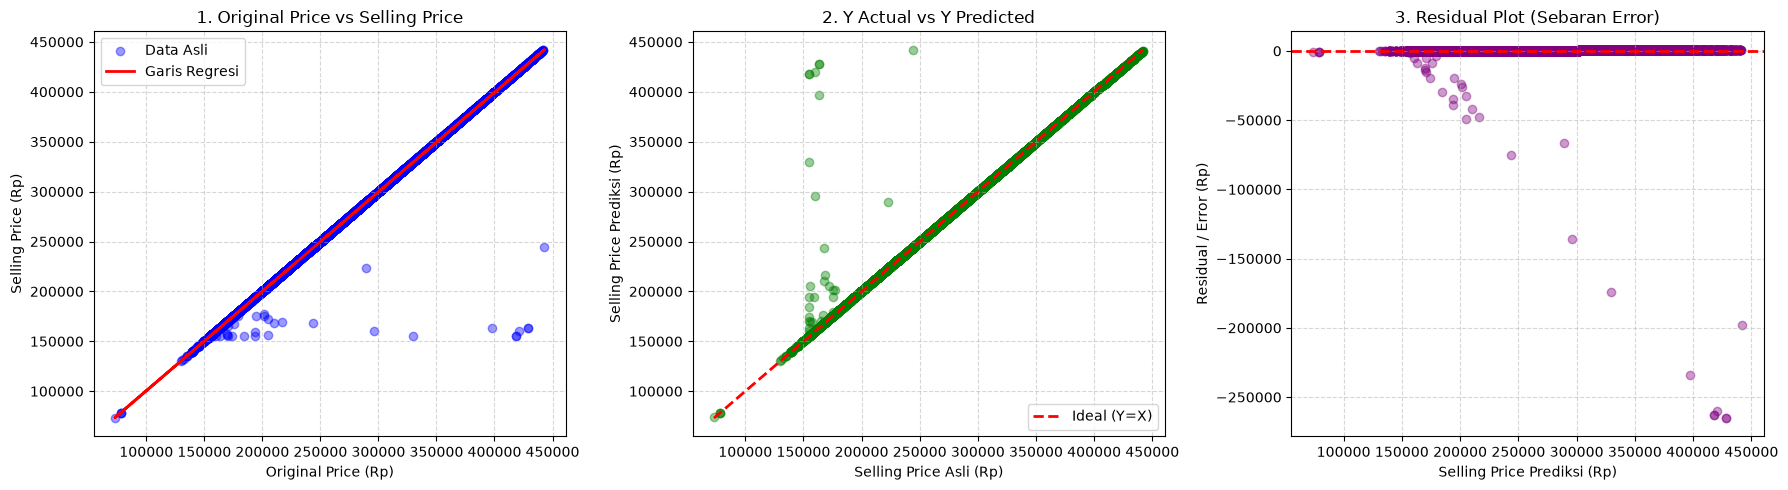

In [61]:
plot_evaluation(x_tr, y_tr, y_pred_tr)

- Untuk hasil plot dari data train, error yang berada di luar garis lumayan banyak dikarenakan ada nilai ekstrim yang belum terhapus, namun mayoritas titik berada pada garis prediksi sehingga model sudah cukup akurat untuk memprediksi selling price.
- Untuk Hasil Residual plot titik2 prediksi mayoritas berada pada titik 0 yang artinya tebakan model hampir akurat, namun ada beberapa titik2 dibawah garis yang menandakan beberapa prediksi selling price lebih tinggi dari harga aslinya

D.6 Plot Data Test

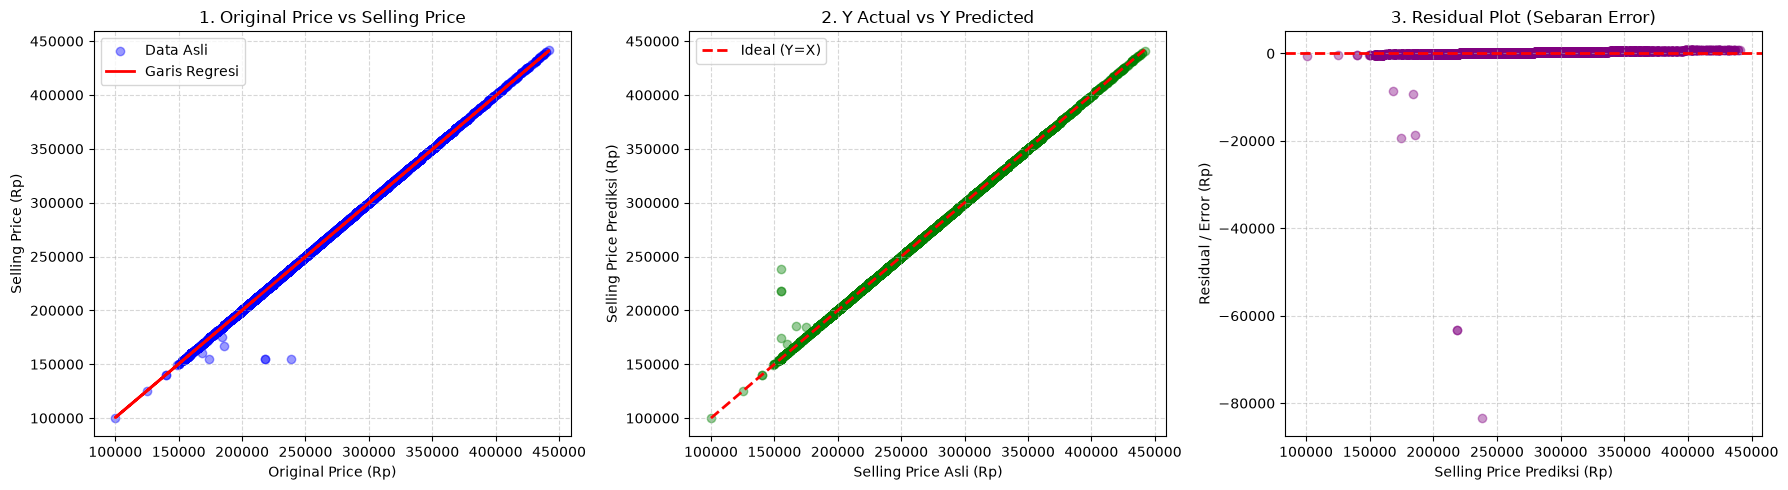

In [62]:
plot_evaluation(x_te, y_te, y_pred_te)

- Untuk hasil plot dari data Test, error yang berada di luar garis Sudah lumayan berkurang sehingga model lebih akurat untuk memprediksi
- Untuk Hasil Residual plot titik2 prediksi mayoritas berada pada titik 0 yang artinya tebakan model hampir akurat, dan untuk titik2 residual atau diluar garis 0 sudah berkurang banyak yang berarti model sudah bisa memprediksi selling price lebih akurat

# E. Graphical User Interface (GUI)

In [63]:
from tkinter import *
from tkinter import messagebox

In [69]:
def submit():
    try:
        x_baru = float(entry_input.get())

    except ValueError:
        messagebox.showerror('Error', 'Please input by Number.')

    y_pred_baru = model.predict(x_baru)
    print(y_pred_baru)
    if x_baru < y_pred_baru:
        messagebox.showinfo('Prediksi', f'Harga router di toko kamu berada di bawah harga pasar. \n Rekomendasi Harga jual: Rp.{y_pred_baru:,.0f}')
    else:
        messagebox.showinfo('Prediksi', f'Harga router di toko kamu berada di atas harga pasar. \n Rekomendasi Harga jual: Rp.{y_pred_baru:,.0f}')

window = Tk()
window.title('Prediksi Harga Discount Router')
window.geometry('450x250')
window.config(bg='teal')

title = Label(window, text='Prediksi Harga Jual Router', bg='teal')
title.pack(pady=5)

label_input = Label(window, text='Masukkan Harga Router Awal dari Toko', font=('Arial', '12'), bg='teal')
label_input.pack(pady=15)

entry_input = Entry(window, width=30, font=('arial', 12))
entry_input.pack(pady=15)

batten = Button(window, text='Predict', relief=FLAT, background='orange', font=('arial', 10, 'bold'), width=25, command=submit)
batten.pack(pady=15)

window.mainloop()

150293.63234142234
498939.84685001726
